### 🛠️ 1. Configuración e Instalaciones
!pip install torch pandas numpy matplotlib imageio tqdm

In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import imageio
import io
import csv
from typing import Callable, Any
from tqdm import tqdm

# Parámetros Globales (Ground Truth)
MASA_REAL = 500.0
CD_REAL = 0.3
ANGULO_REAL = 85.0
ARCHIVO_DATOS = 'vuelo.csv'

### 📐 2. Motor de Integración Numérica (RK4)

In [ ]:
def rk4_step(f: Callable, t: float, y: np.ndarray, dt: float, *args: Any) -> np.ndarray:
    k1 = f(t, y, *args)
    k2 = f(t + dt/2, y + dt/2 * k1, *args)
    k3 = f(t + dt/2, y + dt/2 * k2, *args)
    k4 = f(t + dt, y + dt * k3, *args)
    return y + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

def cinematica_cohete(t: float, state: np.ndarray, masa: float, empuje: float, angulo_deg: float, cd: float) -> np.ndarray:
    x, y_alt, vx, vy = state
    G, RHO_0, H, AREA = 9.81, 1.225, 8500.0, 3.14

    if t < 20.0:
        theta = np.radians(angulo_deg)
    else:
        theta = np.radians(max(0.0, angulo_deg - (t - 20.0) * 2.0))

    rho = RHO_0 * np.exp(-max(0.0, y_alt) / H) if y_alt < 100000.0 else 0.0
    v_mag = np.sqrt(vx**2 + vy**2) + 1e-8
    f_drag = 0.5 * rho * v_mag**2 * cd * AREA

    dx = vx
    dy = vy
    dvx = (empuje * np.cos(theta) - f_drag * (vx / v_mag)) / masa
    dvy = (empuje * np.sin(theta) - f_drag * (vy / v_mag)) / masa - G

    return np.array([dx, dy, dvx, dvy])

### 🚀 3. Simulador de Telemetría (Generación de Datos)

In [ ]:
def generar_datos():
    t, dt, t_final = 0.0, 0.1, 150.0
    state = np.array([0.0, 0.0, 0.0, 0.0])
    empuje = 15000.0

    datos_nominales = []
    while t <= t_final and state[1] >= 0:
        datos_nominales.append([t, state[0], state[1], state[2], state[3]])
        state = rk4_step(cinematica_cohete, t, state, dt, MASA_REAL, empuje, ANGULO_REAL, CD_REAL)
        t += dt

    datos = np.array(datos_nominales)
    sigma_y, sigma_v = 2.0, 0.1
    datos[:, 2] += np.random.normal(0, sigma_y, size=len(datos))
    datos[:, 3] += np.random.normal(0, sigma_v, size=len(datos))
    datos[:, 4] += np.random.normal(0, sigma_v, size=len(datos))

    with open(ARCHIVO_DATOS, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['t', 'x', 'y', 'vx', 'vy'])
        writer.writerows(datos)

    print(f"✅ Telemetría generada: {ARCHIVO_DATOS} ({len(datos)} muestras)")

generar_datos()

✅ Telemetría generada: vuelo.csv (1501 muestras)


### 🧠 4. Arquitectura PINN (Physics-Informed Neural Network)

In [ ]:
class PINN_Drag(nn.Module):
    def __init__(self):
        super(PINN_Drag, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 4)
        )
        self.cd = nn.Parameter(torch.tensor([0.05]))
        self.masa = nn.Parameter(torch.tensor([300.0]))

    def forward(self, t):
        return self.net(t)

def physical_loss(t, state_pred, cd_pred, masa_pred):
    x, y, vx, vy = state_pred[:, 0:1], state_pred[:, 1:2], state_pred[:, 2:3], state_pred[:, 3:4]

    grads = lambda y_p: torch.autograd.grad(y_p, t, grad_outputs=torch.ones_like(y_p), create_graph=True)[0]
    dx_dt, dy_dt, dvx_dt, dvy_dt = grads(x), grads(y), grads(vx), grads(vy)

    g, rho_0, H, area, empuje = 9.81, 1.225, 8500.0, 3.14, 15000.0
    angulo_inicial = np.radians(85.0)

    theta = torch.where(t < 20.0, torch.full_like(t, angulo_inicial),
                        torch.clamp(angulo_inicial - (t - 20.0) * np.radians(2.0), min=0.0))

    v_norm = torch.sqrt(vx**2 + vy**2) + 1e-8
    rho = torch.where(y < 100000.0, rho_0 * torch.exp(-y / H), torch.zeros_like(y))
    F_d = 0.5 * rho * v_norm**2 * cd_pred * area

    res_x = dx_dt - vx
    res_y = dy_dt - vy
    res_vx = dvx_dt - (empuje * torch.cos(theta) / masa_pred) + (F_d / masa_pred) * (vx / v_norm)
    res_vy = dvy_dt - (empuje * torch.sin(theta) / masa_pred) + g + (F_d / masa_pred) * (vy / v_norm)

    return torch.mean(res_x**2 + res_y**2 + res_vx**2 + res_vy**2)

### 🏋️ 5. Entrenamiento y Visualización

Entrenando PINN: 100%|██████████| 3000/3000 [00:46<00:00, 64.96it/s, Loss=1.63e-03, Cd=0.3023, Masa=301.3kg]


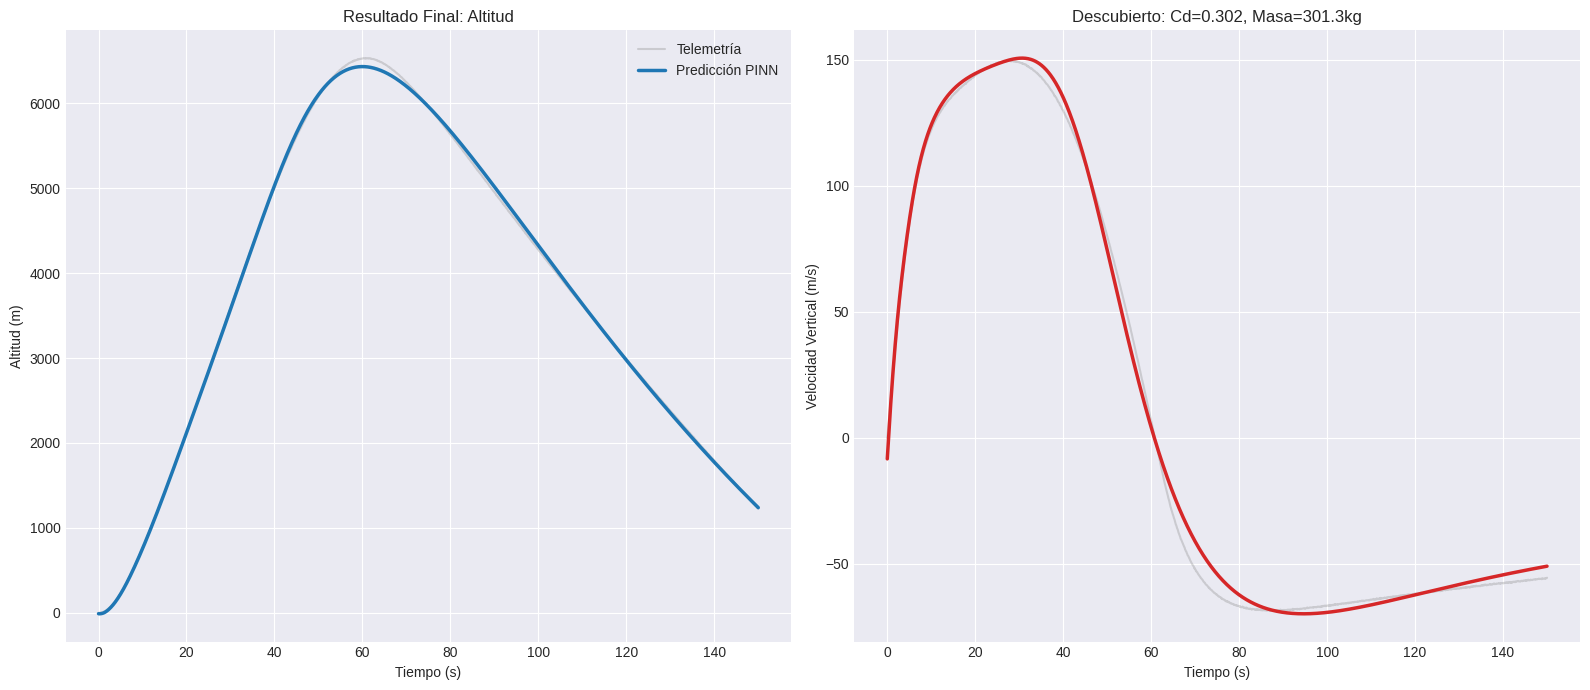

In [ ]:
# Cargar y Normalizar
df = pd.read_csv(ARCHIVO_DATOS)
t_data = torch.tensor(df['t'].values, dtype=torch.float32).view(-1, 1).requires_grad_(True)
state_data = torch.tensor(df[['x', 'y', 'vx', 'vy']].values, dtype=torch.float32)
state_mean, state_std = state_data.mean(dim=0), state_data.std(dim=0) + 1e-8
state_data_norm = (state_data - state_mean) / state_std

model = PINN_Drag()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
plt.style.use('seaborn-v0_8-darkgrid')

loss_history, epochs = [], 3000
pbar = tqdm(range(epochs), desc="Entrenando PINN")

for epoch in pbar:
    optimizer.zero_grad()
    state_pred_norm = model(t_data)
    state_pred = state_pred_norm * state_std + state_mean

    loss_data = nn.MSELoss()(state_pred_norm, state_data_norm)
    loss_physics = physical_loss(t_data, state_pred, model.cd, model.masa)
    loss = loss_data + (1e-5 * loss_physics)
    loss_history.append(loss.item())

    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        pbar.set_postfix({'Loss': f"{loss.item():.2e}", 'Cd': f"{model.cd.item():.4f}", 'Masa': f"{model.masa.item():.1f}kg"})

# Resultados Finales
with torch.no_grad():
    state_final = (model(t_data) * state_std + state_mean).cpu().numpy()
    t_np = t_data.detach().cpu().numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
ax1.plot(t_np, state_data[:, 1], color='gray', alpha=0.3, label="Telemetría")
ax1.plot(t_np, state_final[:, 1], '#1f77b4', linewidth=2.5, label="Predicción PINN")
ax1.set_title("Resultado Final: Altitud")
ax1.set_xlabel("Tiempo (s)")
ax1.set_ylabel("Altitud (m)")
ax1.legend()

ax2.plot(t_np, state_data[:, 3], color='gray', alpha=0.3)
ax2.plot(t_np, state_final[:, 3], '#d62728', linewidth=2.5)
ax2.set_title(f"Descubierto: Cd={model.cd.item():.3f}, Masa={model.masa.item():.1f}kg")
ax2.set_xlabel("Tiempo (s)")
ax2.set_ylabel("Velocidad Vertical (m/s)")
plt.tight_layout()
plt.show()